# Learning by Pruning — 3-Layer Network (Signed-Conserving)

Same experiment as the 2-layer version, but with **two hidden layers**. No weight updates — only forward passes, utility tracking, and pruning.

**Utility function** (loo, signed, signed_derivative, signed):
- **Output layer**: LOO utility with **signed normalization** (rescale so `Σ U_j = error_reduced`)
- **Hidden layer propagation**: **signed pseudo-error** (`e_j = U_j / f'(z_j)`), LOO child scores, **signed normalization** (`Σ U_{k←j} = U_j`, with proportional fallback when `Σ s_k ≈ 0`)

This preserves signed utility across layers, enabling direct cross-layer comparison for pruning.

In [12]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets

# ── Global hyperparameters ────────────────────────────────────────────
HIDDEN1_SIZE = 1000
HIDDEN2_SIZE = 1000
PRUNE_EVERY = 200
PRINT_EVERY = 5_000
TRACE_DECAY = 1.0 - (1.0 / PRUNE_EVERY)
TOTAL_PRUNE_EVENTS = HIDDEN1_SIZE + HIDDEN2_SIZE
N_STEPS = TOTAL_PRUNE_EVENTS * PRUNE_EVERY
RESET_TRACES_ON_PRUNE = False
SEED = 42
SCAN_UNROLL = 10

In [13]:
# ── Load MNIST ────────────────────────────────────────────────────────
train_dataset = datasets.MNIST(root='./data', train=True, download=True)

all_images_np = train_dataset.data.numpy().reshape(-1, 784).astype(np.float32)
all_images_np = (all_images_np / 255.0 - 0.1307) / 0.3081
all_labels_np = train_dataset.targets.numpy()

INPUT_SIZE = 784
OUTPUT_SIZE = 10
print(f'Loaded {len(all_labels_np)} training images')

Loaded 60000 training images


In [14]:
# ── Initialize network weights and pruning masks ─────────────────────
key = jax.random.PRNGKey(SEED)
k1, k2, k3 = jax.random.split(key, 3)

W1 = jax.random.normal(k1, (INPUT_SIZE, HIDDEN1_SIZE)) * np.sqrt(2.0 / INPUT_SIZE)
b1 = jnp.zeros(HIDDEN1_SIZE)
W2 = jax.random.normal(k2, (HIDDEN1_SIZE, HIDDEN2_SIZE)) * np.sqrt(2.0 / HIDDEN1_SIZE)
b2 = jnp.zeros(HIDDEN2_SIZE)
W3 = jax.random.normal(k3, (HIDDEN2_SIZE, OUTPUT_SIZE)) * np.sqrt(2.0 / HIDDEN2_SIZE)
b3 = jnp.zeros(OUTPUT_SIZE)

mask1 = jnp.ones(HIDDEN1_SIZE)
mask2 = jnp.ones(HIDDEN2_SIZE)
utility_trace1 = jnp.zeros(HIDDEN1_SIZE)
utility_trace2 = jnp.zeros(HIDDEN2_SIZE)

print(f'Network: {INPUT_SIZE} -> {HIDDEN1_SIZE} (ReLU) -> {HIDDEN2_SIZE} (ReLU) -> {OUTPUT_SIZE}')
n_params = W1.size + b1.size + W2.size + b2.size + W3.size + b3.size
print(f'Total parameters: {n_params:,}')

Network: 784 -> 1000 (ReLU) -> 1000 (ReLU) -> 10
Total parameters: 1,796,010


In [15]:
def forward(x, W1, b1, W2, b2, W3, b3, mask1, mask2):
    z1 = x @ W1 + b1
    h1 = jax.nn.relu(z1) * mask1
    z2 = h1 @ W2 + b2
    h2 = jax.nn.relu(z2) * mask2
    logits = h2 @ W3 + b3
    return logits, h1, z1, h2, z2


def relu_derivative(z):
    return (z > 0).astype(jnp.float32)


# ── Utility: loo, signed output, signed_derivative, signed hidden ────

def output_layer_loo(h, W_out, y_star, y_hat):
    """Output-layer LOO with signed normalization."""
    e = y_star - y_hat
    c = W_out * h[:, None]                        # (H, OUTPUT_SIZE)
    u_raw = (jnp.abs(e + c) - jnp.abs(e)).sum(axis=1)  # (H,)

    # Signed normalization: rescale so Σ U_j = error_reduced
    error_reduced = jnp.sum(jnp.abs(y_star)) - jnp.sum(jnp.abs(e))
    signed_sum = jnp.sum(u_raw)
    scale = jnp.where(jnp.abs(signed_sum) > 1e-10, error_reduced / signed_sum, 1.0)
    return u_raw * scale


def propagate_utility_signed(h_below, W, z_above, U_parent):
    """Propagate utility with signed conservation.

    1. Signed pseudo-error: e_j = U_j / f'(z_j)
    2. LOO child scores: s[j,k] = |e_j + c_jk| - |e_j|
    3. Signed normalization: U_{k←j} = s_k * U_j / Σ s_k
       Falls back to proportional (by |c_k|) when Σ s_k ≈ 0
    4. Sum over parents
    """
    f_prime = relu_derivative(z_above)
    f_prime_safe = jnp.maximum(f_prime, 1e-6)
    e_j = U_parent / f_prime_safe                            # (H_above,)

    contributions = W * h_below[None, :]                     # (H_above, H_below)

    # LOO scores
    s_raw = jnp.abs(e_j[:, None] + contributions) - jnp.abs(e_j[:, None])

    # Signed normalization with proportional fallback
    s_signed_sum = jnp.sum(s_raw, axis=1, keepdims=True)    # (H_above, 1)
    can_normalize = jnp.abs(s_signed_sum) > 1e-10
    s_signed_safe = jnp.where(can_normalize, s_signed_sum, 1.0)
    U_signed = s_raw * U_parent[:, None] / s_signed_safe

    # Proportional fallback when Σ s_k ≈ 0
    abs_contrib = jnp.abs(contributions)
    abs_contrib_sum = jnp.maximum(jnp.sum(abs_contrib, axis=1, keepdims=True), 1e-10)
    U_fallback = U_parent[:, None] * abs_contrib / abs_contrib_sum

    use_signed = can_normalize.astype(jnp.float32)
    U_from_j = use_signed * U_signed + (1.0 - use_signed) * U_fallback

    return jnp.sum(U_from_j, axis=0)


def _scan_step(carry, data):
    W1, b1, W2, b2, W3, b3, mask1, mask2, ut1, ut2 = carry
    x, label = data

    logits, h1, z1, h2, z2 = forward(x, W1, b1, W2, b2, W3, b3, mask1, mask2)
    correct = (jnp.argmax(logits) == label).astype(jnp.float32)

    one_hot = jax.nn.one_hot(label, OUTPUT_SIZE)

    # Layer 2 utility (hidden2 -> output): LOO + signed normalization
    U2 = output_layer_loo(h2, W3, one_hot, logits)

    # Layer 1 utility (hidden1 -> hidden2): signed pseudo-error + LOO + signed normalization
    U1 = propagate_utility_signed(h1, W2, z2, U2)

    ut2 = ut2 * TRACE_DECAY + U2 * (1 - TRACE_DECAY)
    ut1 = ut1 * TRACE_DECAY + U1 * (1 - TRACE_DECAY)

    carry = (W1, b1, W2, b2, W3, b3, mask1, mask2, ut1, ut2)
    return carry, correct


scan_chunk = jax.jit(
    lambda carry, data: jax.lax.scan(_scan_step, carry, data, unroll=SCAN_UNROLL)
)

In [16]:
# ── Main loop ─────────────────────────────────────────────────────────
assert N_STEPS % PRUNE_EVERY == 0
assert PRINT_EVERY % PRUNE_EVERY == 0
n_prune_events = N_STEPS // PRUNE_EVERY
chunks_per_print = PRINT_EVERY // PRUNE_EVERY

all_corrects = []
n_active1_history = []
n_active2_history = []

rng = np.random.RandomState(SEED)
epoch_order = rng.permutation(len(all_labels_np))
epoch_pos = 0

def get_chunk(size):
    global epoch_order, epoch_pos
    indices = []
    remaining = size
    while remaining > 0:
        avail = len(epoch_order) - epoch_pos
        take = min(avail, remaining)
        indices.append(epoch_order[epoch_pos:epoch_pos + take])
        epoch_pos += take
        remaining -= take
        if epoch_pos >= len(epoch_order):
            epoch_order = rng.permutation(len(all_labels_np))
            epoch_pos = 0
    indices = np.concatenate(indices)
    return all_images_np[indices], all_labels_np[indices]

carry = (W1, b1, W2, b2, W3, b3, mask1, mask2, utility_trace1, utility_trace2)

for prune_idx in range(n_prune_events):
    images_chunk, labels_chunk = get_chunk(PRUNE_EVERY)
    data = (jnp.array(images_chunk), jnp.array(labels_chunk))

    carry, corrects = scan_chunk(carry, data)
    all_corrects.append(np.array(corrects))

    W1, b1, W2, b2, W3, b3, mask1, mask2, utility_trace1, utility_trace2 = carry
    n_active1 = int(mask1.sum())
    n_active2 = int(mask2.sum())
    n_active1_history.append(n_active1)
    n_active2_history.append(n_active2)

    # Prune the single lowest-utility unit across both layers
    score1 = jnp.where(mask1 > 0.5, utility_trace1, jnp.inf)
    score2 = jnp.where(mask2 > 0.5, utility_trace2, jnp.inf)
    min1 = jnp.min(score1)
    min2 = jnp.min(score2)

    can_prune1 = n_active1 > 1
    can_prune2 = n_active2 > 1

    if can_prune1 or can_prune2:
        # Pick the layer with the lower minimum (only among pruneable layers)
        prune_layer1 = can_prune1 and (not can_prune2 or min1 <= min2)
        if prune_layer1:
            worst = jnp.argmin(score1)
            mask1 = mask1.at[worst].set(0.0)
        else:
            worst = jnp.argmin(score2)
            mask2 = mask2.at[worst].set(0.0)

        if RESET_TRACES_ON_PRUNE:
            utility_trace1 = jnp.zeros(HIDDEN1_SIZE)
            utility_trace2 = jnp.zeros(HIDDEN2_SIZE)

    carry = (W1, b1, W2, b2, W3, b3, mask1, mask2, utility_trace1, utility_trace2)

    step_num = (prune_idx + 1) * PRUNE_EVERY
    if step_num % PRINT_EVERY == 0:
        recent_chunks = all_corrects[-chunks_per_print:]
        recent_acc = float(np.concatenate(recent_chunks).mean()) * 100
        print(f'Step {step_num:>7d} | L1: {n_active1:>4d} | L2: {n_active2:>4d} | '
              f'Acc: {recent_acc:.1f}%')

print(f'\nDone. Active units — L1: {int(mask1.sum())} / {HIDDEN1_SIZE}, '
      f'L2: {int(mask2.sum())} / {HIDDEN2_SIZE}')

Step    5000 | L1:  976 | L2: 1000 | Acc: 12.0%
Step   10000 | L1:  951 | L2: 1000 | Acc: 10.4%
Step   15000 | L1:  926 | L2: 1000 | Acc: 9.2%
Step   20000 | L1:  901 | L2: 1000 | Acc: 8.6%
Step   25000 | L1:  876 | L2: 1000 | Acc: 9.3%
Step   30000 | L1:  851 | L2: 1000 | Acc: 9.1%
Step   35000 | L1:  826 | L2: 1000 | Acc: 8.0%
Step   40000 | L1:  801 | L2: 1000 | Acc: 8.1%
Step   45000 | L1:  776 | L2: 1000 | Acc: 8.6%
Step   50000 | L1:  751 | L2: 1000 | Acc: 8.5%
Step   55000 | L1:  726 | L2: 1000 | Acc: 7.9%
Step   60000 | L1:  701 | L2: 1000 | Acc: 9.4%
Step   65000 | L1:  676 | L2: 1000 | Acc: 10.1%
Step   70000 | L1:  651 | L2: 1000 | Acc: 8.7%
Step   75000 | L1:  626 | L2: 1000 | Acc: 8.5%
Step   80000 | L1:  601 | L2: 1000 | Acc: 10.0%
Step   85000 | L1:  576 | L2: 1000 | Acc: 9.5%
Step   90000 | L1:  551 | L2: 1000 | Acc: 9.4%
Step   95000 | L1:  526 | L2: 1000 | Acc: 9.5%
Step  100000 | L1:  501 | L2: 1000 | Acc: 7.8%
Step  105000 | L1:  476 | L2: 1000 | Acc: 7.9%
Step  110

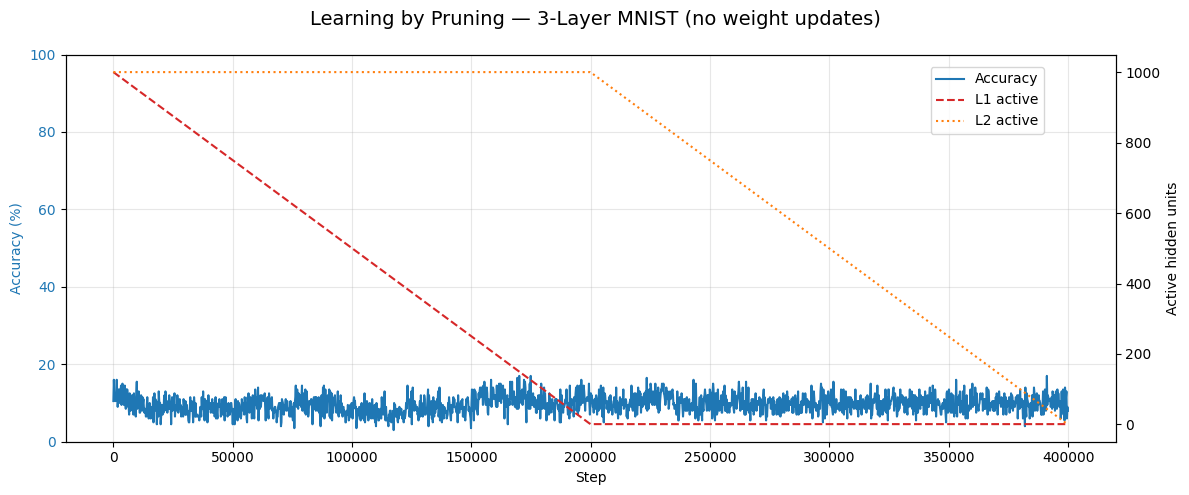

In [17]:
# ── Plot ───────────────────────────────────────────────────────────────
acc_per_interval = [chunk.mean() * 100 for chunk in all_corrects]
interval_centers = [(i + 0.5) * PRUNE_EVERY for i in range(len(acc_per_interval))]

fig, ax1 = plt.subplots(figsize=(12, 5))

color_acc = 'tab:blue'
ax1.plot(interval_centers, acc_per_interval, color=color_acc, linewidth=1.5, label='Accuracy')
ax1.set_xlabel('Step')
ax1.set_ylabel('Accuracy (%)', color=color_acc)
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(interval_centers, n_active1_history, color='tab:red', linewidth=1.5,
         linestyle='--', label='L1 active')
ax2.plot(interval_centers, n_active2_history, color='tab:orange', linewidth=1.5,
         linestyle=':', label='L2 active')
ax2.set_ylabel('Active hidden units')

fig.suptitle('Learning by Pruning — 3-Layer MNIST (no weight updates)', fontsize=14)
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
fig.tight_layout()
plt.show()